In [1]:
import numpy as np
import torch as th
import matplotlib.pyplot as plt
import json, os
import subprocess

os.environ['CUDA_VISIBLE_DEVICES'] = '2'
model = 'log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_dstL'
n_frames = 60
ckpt = 'ema_300000'
sample_folder = '/data/mint/sampling/TPAMI/main_result/ffhq/for_video_supp/'
sample_json = '/home/mint/Dev/DiFaReli/difareli-faster/experiment_scripts/TPAMI/sample_json/DiFaReli++/video_supp.json'
pf = '/valid/render_face/reverse_sampling/'

grid_size = 3
path = f'{sample_folder}/{model}/{ckpt}/{pf}/'

with open(sample_json, 'r') as f:
    sj = json.load(f)['pair']


vids = []
for pid, pair in sj.items():
    tmp = f'{path}/src={pair["src"]}/dst={pair["dst"]}/Lerp_1000/n_frames={n_frames}/'
    vid = f'{tmp}/res.mp4'
    vids.append(vid)
    
# Use ffmpeg to concatenate videos as a grid into one following the grid size
# Generate the FFmpeg command
input_cmds = []
for i, vid in enumerate(vids[:grid_size**2]):
    input_cmds.append(f"-i {vid}")

# Prepare xstack filter to form a 5x5 grid
layout = []
for row in range(grid_size):
    for col in range(grid_size):
        # Calculate the position based on `w` and `h` values
        # w0, w1, etc. represent the cumulative width up to the column index
        # h0, h1, etc. represent the cumulative height up to the row index
        x_pos = "+".join([f"w{c}" for c in range(col)]) if col > 0 else "0"
        y_pos = "+".join([f"h{r}" for r in range(row)]) if row > 0 else "0"
        layout.append(f"{x_pos}_{y_pos}")

xstack_filter = f"xstack=inputs={grid_size**2}:layout=" + "|".join(layout)
print(xstack_filter)


output_path = './grid1.mp4'
# Complete the FFmpeg command
ffmpeg_cmd = f"ffmpeg -y {' '.join(input_cmds)} -filter_complex \"{xstack_filter}\" -c:v libx264 -crf 23 -preset veryfast {output_path}"

# Run the command
subprocess.run(ffmpeg_cmd, shell=True)

xstack=inputs=9:layout=0_0|w0_0|w0+w1_0|0_h0|w0_h0|w0+w1_h0|0_h0+h1|w0_h0+h1|w0+w1_h0+h1


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

CompletedProcess(args='ffmpeg -y -i /data/mint/sampling/TPAMI/main_result/ffhq/for_video_supp//log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_dstL/ema_300000//valid/render_face/reverse_sampling///src=63295.jpg/dst=60065.jpg/Lerp_1000/n_frames=60//res.mp4 -i /data/mint/sampling/TPAMI/main_result/ffhq/for_video_supp//log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_dstL/ema_300000//valid/render_face/reverse_sampling///src=69545.jpg/dst=60065.jpg/Lerp_1000/n_frames=60//res.mp4 -i /data/mint/sampling/TPAMI/main_result/ffhq/for_video_supp//log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_dstL/ema_300000//valid/render_face/reverse_sampling///src=66943.jpg/dst=60065.jpg/Lerp_1000/n_frames=60//res.mp4 -i /data/mint/sampling/TPAMI/main_result/ffhq/for_video_supp//log=paired+difareli+cs+nodpm+trainset_256_cfg=paired+difareli+cs+nodpm+trainset_256.yaml_rot2_dstL

# Rotate indicators

In [2]:
import misc
import imp
import copy, sys, time, tqdm
from PIL import Image

sys.path.append("/home/mint/Dev/DiFaReli/difareli-faster/sample_scripts/sample_utils/")
import mani_utils, params_utils
imp.reload(params_utils)
rasterize_type = 'standard'
n_frames_render = 60
import misc
set_ = 'valid'
deca_params, avg_dict = misc.load_deca_params(deca_dir=f'/data/mint/DPM_Dataset/eval_request/Sumit/params/{set_}', cfg=None)
start_t = time.time()
mask = params_utils.load_flame_mask()
deca_obj = params_utils.init_deca(mask=mask, rasterize_type=rasterize_type)
print(f"[#] Time taken to load DECA: {time.time()-start_t}")

def render(cond, axis=None, sd=256, out='deca_rendered'):
    render_mode = 'shape'
    rotate_normals = False
    sub_step = mani_utils.ext_sub_step(n_step, render_batch_size)
    cond_mod = copy.deepcopy(cond)
    out_deca = []
    out_ball = []
    out_shadow = []
    for i in tqdm.tqdm(range(len(sub_step)-1), desc='[#] Rendering...'):
        start = sub_step[i]
        end = sub_step[i+1]
        sub_cond = cond_mod.copy()
        sub_cond['light'] = sub_cond['light'][start:end, :]
        # Deca rendered : B x 3 x H x W
        deca_rendered, orig_visdict = params_utils.render_deca(deca_params=sub_cond, 
                                                            idx=0, n=end-start, 
                                                            avg_dict=avg_dict, 
                                                            render_mode=render_mode, 
                                                            rotate_normals=rotate_normals, 
                                                            mask=mask,
                                                            deca_obj=deca_obj,
                                                            repeat=True)
        shadow_mask, shadow_kk, render_ld = params_utils.render_shadow_mask_with_smooth(
                                sh_light=sub_cond['light'], 
                                cam=sub_cond['cam'][0],
                                verts=orig_visdict['trans_verts_orig'], 
                                use_sh_to_ld_region=False,
                                # deca={'face_scalp':deca_obj_face_scalp}, 
                                deca={'face_scalp':deca_obj}, 
                                axis_0=axis==0,
                                axis_1=axis==1,
                                device='cpu',   # Prevent OOM
                                up_rate=1,
                                org_h=256, org_w=256,
                                rt_dict={'pt_round':1, 'pt_radius':0.2, 'rt_regionG_scale':False, 'scale_depth':sd}
                            )
        ball_rendered = []
        for l in range(sub_cond['light'].shape[0]):
            ball_rendered.append(misc.drawSphere(sh=th.tensor(sub_cond['light'][l]).view(9, 3)))
        ball_rendered = np.stack(ball_rendered, 0)
        deca_rendered = deca_rendered.cpu().numpy()
        out_deca.append(deca_rendered)
        out_ball.append(ball_rendered)
        out_shadow.append(shadow_mask)
        
    out_deca = np.concatenate(out_deca, 0)
    out_ball = np.concatenate(out_ball, 0)
    out_shadow = np.concatenate(out_shadow, 0)
    out_shadow = np.stack([out_shadow]*3, 1)
    
    print("DECA: ", out_deca.shape, out_deca.min(), out_deca.max())
    print("BALL: ", out_ball.shape, out_ball.min(), out_ball.max())
    print("SHADOW: ", out_shadow.shape, out_shadow.min(), out_shadow.max())
    # Vis all images
    import matplotlib.pyplot as plt
    n_frames = out_deca.shape[0]
    fig, axs = plt.subplots(1, n_frames, figsize=(25, 25))
    for i in range(n_frames):
        axs[i].imshow(np.clip(out_deca[i], 0, 1.0).transpose(1, 2, 0))
        axs[i].axis('off')
    plt.show()
    fig, axs = plt.subplots(1, n_frames, figsize=(25, 25))
    for i in range(n_frames):
        axs[i].imshow(out_ball[i].transpose(1, 2, 0))
        axs[i].axis('off')
    plt.show()
    fig, axs = plt.subplots(1, n_frames, figsize=(25, 25))
    for i in range(n_frames):
        axs[i].imshow(out_shadow[i].transpose(1, 2, 0))
        axs[i].axis('off')
    plt.show()

    return out_deca, out_ball, out_shadow

/tmp/ipykernel_603850/1939407318.py:2: DeprecationWarning: the imp module is deprecated in favour of importlib; see the module's documentation for alternative uses
  import imp
Loading deca params...: 100%|██████████| 10/10 [00:00<00:00, 149.63it/s]


creating the FLAME Decoder
USING STARDARD...
/home/mint/Dev/DiFaReli/difareli-faster/sample_scripts/cond_utils/DECA/decalib/utils
[#] DECA : SRenderY applied mask
[#] Time taken to load DECA: 16.745994806289673


In [3]:
# Load params
deca_params, avg_dict = misc.load_deca_params(deca_dir=f'/data/mint/DPM_Dataset/ffhq_256_with_anno/params/{set_}', cfg=None)

Loading deca params...: 100%|██████████| 10/10 [00:07<00:00,  1.36it/s]


[#] Rendering...:   0%|          | 0/1 [00:00<?, ?it/s]

[#] Rendering shadow mask with smooth (pertubation version)...
[#] Scale depth with 256...
[#] Approximate the light direction from the mean of SH coffecients [2nd, 3rd and 4th] ...


[#] Rendering...: 100%|██████████| 1/1 [00:25<00:00, 25.72s/it]


DECA:  (60, 3, 256, 256) -0.020142948 1.3236375
BALL:  (60, 3, 256, 256) 0.0 1.0
SHADOW:  (60, 3, 256, 256) 0.0 0.9996724


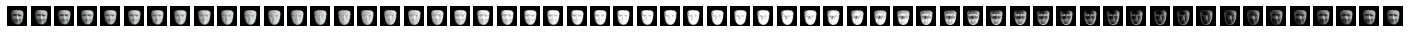

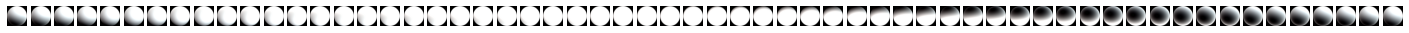

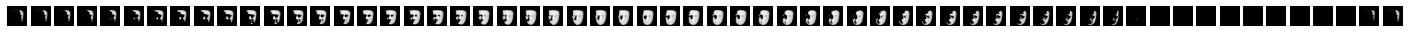

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

[#] Rendering shadow mask with smooth (pertubation version)...
[#] Scale depth with 256...
[#] Approximate the light direction from the mean of SH coffecients [2nd, 3rd and 4th] ...


[#] Rendering...: 100%|██████████| 1/1 [00:25<00:00, 25.61s/it]


DECA:  (60, 3, 256, 256) -0.020264775 1.3241341
BALL:  (60, 3, 256, 256) 0.0 1.0
SHADOW:  (60, 3, 256, 256) 0.0 0.9996724


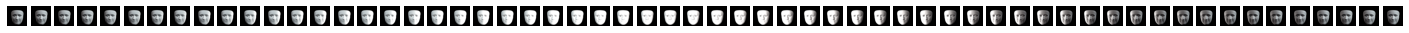

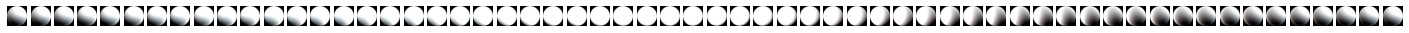

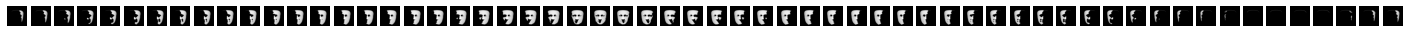

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

[#] Rendering shadow mask with smooth (pertubation version)...
[#] Scale depth with 256...
[#] Approximate the light direction from the mean of SH coffecients [2nd, 3rd and 4th] ...


[#] Rendering...: 100%|██████████| 1/1 [00:25<00:00, 25.46s/it]


DECA:  (60, 3, 256, 256) -0.020586155 0.904966
BALL:  (60, 3, 256, 256) 0.0 1.0
SHADOW:  (60, 3, 256, 256) 0.0 0.9996724


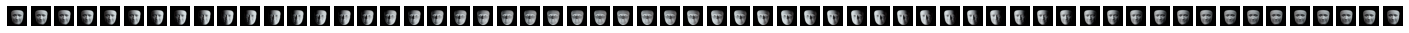

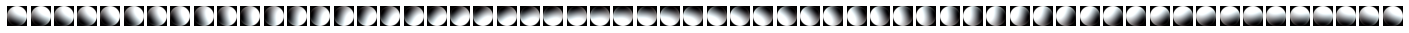

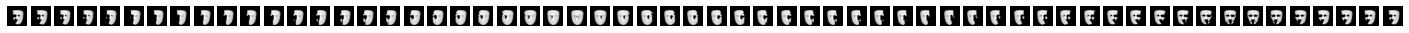

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [41]:
# Load the DeCA model
imp.reload(params_utils)
sj = '60065.jpg'
rotate_sh_axis = 0
n_step = 60
src_idx = 0
cond = copy.deepcopy(deca_params[sj])
render_batch_size = 60
for k in cond.keys():
    cond[k] = th.tensor(cond[k][None, ...])
cond['raw_image_path'] = [f'/data/mint/DPM_Dataset/ffhq_256_with_anno/ffhq_256/{set_}/{sj}']
cond['raw_image'] = th.tensor(np.array(Image.open(cond['raw_image_path'][0]))).permute(2, 0, 1)[None, ...]

# print("Input SH: ", cond['light'].shape)
# print("Target SH: ", render_cond['light'].shape)
# interp_cond.update(mani_utils.interp_cond(cond['light'], deca_params['output.png']['light'], n_step, interp_fn=mani_utils.lerp))
render_cond = copy.deepcopy(cond)
render_cond.update(mani_utils.rotate_sh(cond, src_idx=src_idx, n_step=n_step, axis=0))
out_deca, out_ball, out_shadow = render(render_cond, sd=256, axis=0)
save_vid([out_deca, out_ball, out_shadow], f'./{sj}_axis0.mp4')
render_cond = copy.deepcopy(cond)
render_cond.update(mani_utils.rotate_sh(cond, src_idx=src_idx, n_step=n_step, axis=1))
out_deca, out_ball, out_shadow = render(render_cond, sd=256, axis=1)
save_vid([out_deca, out_ball, out_shadow], f'./{sj}_axis1.mp4')

render_cond = copy.deepcopy(cond)
render_cond.update(mani_utils.rotate_sh(cond, src_idx=src_idx, n_step=n_step, axis=2))
out_deca, out_ball, out_shadow = render(render_cond, sd=256, axis=2)
save_vid([out_deca, out_ball, out_shadow], f'./{sj}_axis2.mp4')


In [35]:
def save_vid(out, out_name):
    out_deca = out[0]
    out_ball = out[1]
    out_shadow = out[2]
    import torchvision.io as tvio
    tvio.write_video('deca.mp4', th.tensor(np.clip(out_deca, 0, 1.0) * 255).permute(0, 2, 3, 1), 30)
    tvio.write_video('shadow.mp4', th.tensor(np.clip(out_shadow, 0, 1.0) * 255).permute(0, 2, 3, 1), 30)
    tvio.write_video('ball.mp4', th.tensor(out_ball * 255).permute(0, 2, 3, 1), 30)
    os.system(f'ffmpeg -y -i ball.mp4 -i deca.mp4 -i shadow.mp4 -filter_complex hstack=inputs=3 {out_name}.mp4')